# 04 · Multivariate EDA: choosing the inputs for booking segmentation

**Task:** P2-07 · **Owner:** M1 (Mahdhi S.M.M) · **Phase:** 2 (EDA)

**Input:** `data/processed/hotel_bookings_preprocessed.csv`, the same cleaned data used in 02 and 03.

**Output:** the candidate clustering feature list (Step 7) and the Top 5 insights for the EDA Insights tab. **No data is changed or saved in this notebook.**

---

## Purpose

Our project has two parts:

- **Supervised part (classification):** predict how likely each booking is to cancel. The bivariate EDA (`03_eda_bivariate`, M3) supports this part by comparing each feature with the target `is_canceled`.
- **Unsupervised part (clustering):** group similar bookings into a small number of segments, so the revenue manager can set **one deposit rule per segment** instead of judging ~87,000 bookings one by one.

**This notebook supports the unsupervised part.** It is still a multivariate EDA, but it asks a different question from 03: it looks at how features relate to **each other** (not to the target) in order to (1) find natural groups in the bookings and (2) choose which columns go into the clustering in `12_clustering`.

> **Key rule:** clustering is *unsupervised*, which means it never sees the answer. `is_canceled` is **never** a clustering input, and it is not used anywhere in this notebook.

## Why the choice of columns matters

Clustering methods such as K-Means put two bookings in the same group when their values are **close**. In other words, they measure a *distance* between bookings. Any column that makes that distance misleading will make the groups misleading. Each step below checks for one way this can happen.

## How to read this notebook

Every step has the same three parts:

- **What we check:** one sentence.
- **Why:** in plain words. Technical terms are explained the first time they appear.
- **What we found → decision:** the numbers from the output, and what we do because of them.

Findings from earlier notebooks are referenced by name (for example *02_eda_univariate, Finding 4* or *EDA-II-9*) so every claim can be traced back to its evidence.

## Steps

1. Setup and load
2. Column inventory: which columns can never go into clustering
3. Near-constant columns
4. Redundant columns
5. Skew: does a log transform help?
6. Pairplot: do bookings form visible groups?
7. Final candidate clustering feature list
8. Top 5 insights and sheet updates

## Step 1 · Setup and load

**What we check:** that we use exactly the same cleaned data as `02_eda_univariate` and `03_eda_bivariate`.

**Why:** if the EDA notebooks use different data, their findings can't be compared with each other. This file is the result of the Type 1 cleaning by M4:
- duplicate rows removed (D-1)
- rows with a missing `country` or `children` removed (D-2)
- missing `agent` / `company` filled with 0 (D-3)

**About the path:** it starts with `../` because Jupyter runs from inside the `notebooks/` folder, and `..` means "go up one folder" to the repo root. It is still a relative path, as the team rules require.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)  # show every column when printing a table

# Same cleaned file as 02 and 03
df = pd.read_csv("../data/processed/hotel_bookings_preprocessed.csv")

# The file was saved with its row index, which comes back as "Unnamed: 0".
# That index is the booking's row number, so we keep it as booking_id (team rule)
if "Unnamed: 0" in df.columns:
    df = df.rename(columns={"Unnamed: 0": "booking_id"})

print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (86940, 33)


In [ ]:
# Quick check of booking_id:
# - unique means one row per booking
# - a highest value close to 119,389 means it is the ORIGINAL row number from the raw file
#   (the raw file had 119,390 rows, numbered 0 to 119,389)
if "booking_id" in df.columns:
    print("booking_id unique:", df["booking_id"].is_unique)
    print("highest booking_id:", df["booking_id"].max())

df.head()

booking_id unique: True
highest booking_id: 119389


,booking_id,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


**What we found:** the shape is **(86,940, 33)**: 86,940 rows, the same as `03_eda_bivariate`, and 33 columns (the original 32 plus `booking_id`). `booking_id` is unique (one row per booking), and its highest value is **119,389**, the last row number of the raw file. So these are the original row numbers, kept through the cleaning.

**Why `Unnamed: 0` became `booking_id`:** when a table is saved with `to_csv()` without `index=False`, pandas writes the row index as an extra column. When the file is read back, that column is called `Unnamed: 0`. The index here is the booking's row number, which is exactly what the team uses as `booking_id`, so we keep it under that name instead of dropping it. It is never used as a feature. It exists only so that, in Phase 6, cluster labels and cancellation probabilities can be joined booking by booking.

## Step 2 · Column inventory

**Why:** before we look for groups, we label every column and set aside the ones that must **never** go into clustering. Nothing is deleted from the data here: set-aside columns simply don't go on to Steps 3–5 or into the final clustering list (Step 7). The classifiers can still use them.

| Role | Meaning | Evidence |
|---|---|---|
| **Target** | The answer we predict (`is_canceled`). Clustering is unsupervised, so it never sees it. | Team plan, P4-06 |
| **Row key** | `booking_id`. It's a row label, not information about the booking. | Team rule: keep `booking_id` in every file |
| **Banned** | Not known at the moment the booking is made, so it would leak information from the future. | D-5, D-7; Data Dictionary ("Known at booking?" = No) |
| **ID code** | `agent` and `company`. Numbers that are *labels*, not amounts, and there are too many of them to use as categories. | EDA-II-8 (03, M3); 02_eda_univariate Finding 5 (M2): 333 agents, 350 companies |
| **Calendar detail** | Describes *when the data was collected*, not *what kind of booking* it is. | EDA-II-10 (03, M3) |
| **Candidate** | Everything else. Goes on to Steps 3–5. | |

**Notes on the lists below:**
- **Banned:** D-5 (parking spaces, special requests) and D-7 (reservation status and its date) are already logged. The other five are marked "No" in the Data Dictionary and are waiting for the team review (P1-06). If P1-06 changes the list, edit `banned` below and re-run the notebook. Every later step updates by itself.
- **ID codes:** there are two problems, whichever way we use them.
  - *As numbers:* agent 240 would count as "close" to agent 241 and "far" from agent 9, but the numbers are just names, so these distances mean nothing. Agent 0 means "no agent at all" (D-3), yet it would count as close to agent 1.
  - *As categories:* one-hot encoding (one 0/1 column per agent or company) would add about 680 columns next to our ~12 real features. Distance adds up over all columns, so the clusters would mostly reflect *which agency booked*, and most agencies have under 1% of bookings (02 Finding 5).
  - The useful part may be a simple *"booked through an agent: yes/no"* flag. This single 0/1 column is considered in notebook 12.
- **Calendar detail:** three date columns are set aside, each for a different reason:
  - `arrival_date_year`: describes *when the data was collected*, not the booking. Future bookings (2026+) would fall into years the clustering has never seen (EDA-II-10).
  - `arrival_date_week_number`: repeats what `arrival_date_month` already says (week 29 = July), so the season would be counted twice (EDA-II-10).
  - `arrival_date_day_of_month`: arriving on "the 14th" says nothing about what kind of booking it is (our own call).
  - `arrival_date_month` **stays a candidate**: season is a real booking trait that repeats every year, and the pattern differs by hotel (EDA-II-6).

In [ ]:
target = ["is_canceled"]

row_key = ["booking_id"]

banned = [
    "reservation_status", "reservation_status_date",                 # D-7
    "required_car_parking_spaces", "total_of_special_requests",      # D-5
    "assigned_room_type", "booking_changes", "days_in_waiting_list", # Data Dictionary: "No" (P1-06)
    "country", "customer_type",                                      # Data Dictionary: "No" (P1-06)
]

id_codes = ["agent", "company"]                                      # EDA-II-8, 02 Finding 5

calendar_detail = [
    "arrival_date_year",          # when the data was collected; future years are unseen (EDA-II-10)
    "arrival_date_week_number",   # repeats arrival_date_month, so the season would count twice (EDA-II-10)
    "arrival_date_day_of_month",  # says nothing about the kind of booking (our own call)
]
# arrival_date_month is NOT in this list: season is a real booking trait, so it stays a candidate (EDA-II-6)

# Safety check: catch typos. Every name above should exist in df
all_listed = target + row_key + banned + id_codes + calendar_detail
not_found = [col for col in all_listed if col not in df.columns]
print("Listed but not found in df:", not_found)  # should be an empty list

Listed but not found in df: []


In [ ]:
# Give every column its role
roles = []
for col in df.columns:
    if col in target:
        role = "Target"
    elif col in row_key:
        role = "Row key"
    elif col in banned:
        role = "Banned"
    elif col in id_codes:
        role = "ID code"
    elif col in calendar_detail:
        role = "Calendar detail"
    else:
        role = "Candidate"
    roles.append(role)

inventory = pd.DataFrame({"column": df.columns, "role": roles})

# Candidates are the only columns that go on to Steps 3-5
candidates = inventory.loc[inventory["role"] == "Candidate", "column"].tolist()

print(inventory["role"].value_counts())
print()
print(len(candidates), "candidates:", candidates)

role
Candidate          17
Banned              9
Calendar detail     3
ID code             2
Row key             1
Target              1
Name: count, dtype: int64

17 candidates: ['hotel', 'lead_time', 'arrival_date_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'deposit_type', 'adr']


**What we found → decision:** 16 of 33 columns are set aside by role: 1 target, 1 row key, 9 banned, 2 ID codes and 3 calendar details. The remaining **17 candidates** go on to Step 3:
`hotel`, `lead_time`, `arrival_date_month`, `stays_in_weekend_nights`, `stays_in_week_nights`, `adults`, `children`, `babies`, `meal`, `market_segment`, `distribution_channel`, `is_repeated_guest`, `previous_cancellations`, `previous_bookings_not_canceled`, `reserved_room_type`, `deposit_type`, `adr`.

## Step 3 · Near-constant columns

**What we check:** for each candidate, the share of bookings that have its most common value.

**Why:** picture a column where 98% of bookings have the same value. For almost every pair of bookings, the distance on that column is 0, so it tells the clustering nothing. Its only effect is to separate the rare 2%, which then risk forming a tiny cluster of their own.

We flag a column as **near-constant** when one value covers **95% or more** of bookings. 95% is a common rule of thumb, not a law, so the choice is logged in the Decision Log (D-8).

**Expected from earlier EDA:**
- *02_eda_univariate, Finding 4 (M2):* `deposit_type` (about 98.7% "No Deposit"), `is_repeated_guest` and `distribution_channel` are dominated by one category.
- *02_eda_univariate, Finding 2 (M2):* count columns such as `babies`, `previous_cancellations` and `previous_bookings_not_canceled` are concentrated at 0.

Here we measure all candidates **side by side, on the cleaned data**, with one threshold.

> **Important:**  Dropping a column here only affects the clustering. The classifiers can still keep it.

In [ ]:
THRESHOLD = 0.95  # 95%, see D-8

rows = []
for col in candidates:
    shares = df[col].value_counts(normalize=True)  # share of each value, largest first
    rows.append({
        "column": col,
        "most_common_value": shares.index[0],
        "top_share_%": round(shares.iloc[0] * 100, 2),
    })

near_constant_table = pd.DataFrame(rows).sort_values("top_share_%", ascending=False)
near_constant_table["near_constant"] = near_constant_table["top_share_%"] >= THRESHOLD * 100

near_constant_cols = near_constant_table.loc[near_constant_table["near_constant"], "column"].tolist()

print("Near-constant (one value covers 95%+ of bookings):", near_constant_cols)
near_constant_table

Near-constant (one value covers 95%+ of bookings): ['babies', 'deposit_type', 'previous_cancellations', 'previous_bookings_not_canceled', 'is_repeated_guest']


,column,most_common_value,top_share_%,near_constant
7,babies,0,98.95,True
15,deposit_type,No Deposit,98.68,True
12,previous_cancellations,0,98.09,True
13,previous_bookings_not_canceled,0,96.18,True
11,is_repeated_guest,0,96.08,True
6,children,0.0,90.39,False
10,distribution_channel,TA/TO,79.40,False
8,meal,BB,77.71,False
5,adults,2,74.01,False
14,reserved_room_type,A,64.63,False


**What we found:** 5 of the 17 candidates are near-constant (one value covers 95%+ of bookings): `babies` (98.95% are 0), `deposit_type` (98.68% "No Deposit", matching 02_eda_univariate Finding 4), `previous_cancellations` (98.09% are 0), `previous_bookings_not_canceled` (96.18% are 0) and `is_repeated_guest` (96.08% are 0).

There is a natural gap between `is_repeated_guest` (96.08%) and the next column, `children` (90.39%). Any threshold between about 91% and 96% gives the same five columns, so the result does not depend on choosing exactly 95%. At 90%, `children` would also be dropped; at 99%, none would be. `children` is lopsided but below the line, so it stays a candidate and is reviewed again in Step 5.

**Decision:** these 5 columns are dropped from the **clustering** inputs only (D-8). The classifiers keep them; for example `previous_cancellations` is a strong cancellation signal (EDA-II-4) and reaches the deposit policy through the risk score. 12 candidates go on to Step 4.

## Step 4 · Redundant columns

**What we check:** whether two columns carry the same information.

**Why:** if two columns say the same thing, the clustering counts that fact twice, so it gets double weight in the distance compared with everything else.

**Numeric columns (from earlier EDA, not repeated here):** `03_eda_bivariate` (M3) already checked these.
- All VIF values are below 2 (EDA-II-11), so there is no serious overlap. VIF, the *variance inflation factor*, measures how well one column can be predicted from all the others.
- The strongest pair is `stays_in_weekend_nights` and `stays_in_week_nights` (correlation 0.551, EDA-II-9). That is moderate, not redundant, so both stay for now. EDA-II-9 notes that combining them into total nights is more worthwhile for clustering than for prediction; that option is considered in notebook 12.

**Categorical columns (new in this notebook):** we check two pairs.
1. **`market_segment` × `distribution_channel`.** This is a follow-up from `03_eda_bivariate` (M3), which flagged a possible overlap (*"Keep, but check redundancy with market_segment"*). 03 compares features with the target, so this feature-vs-feature check belongs here.
2. **`is_repeated_guest` × "has any previous booking".** A repeat guest should, by definition, have earlier bookings, so these may say the same thing.

**How to read the tables:** we use `pd.crosstab(..., normalize="index")`, which turns each row into percentages that add up to 100%. Read a row as: *"of all Online TA bookings, X% came through the TA/TO channel."* If most rows have one cell close to 100%, one column can be predicted from the other, so they are redundant.

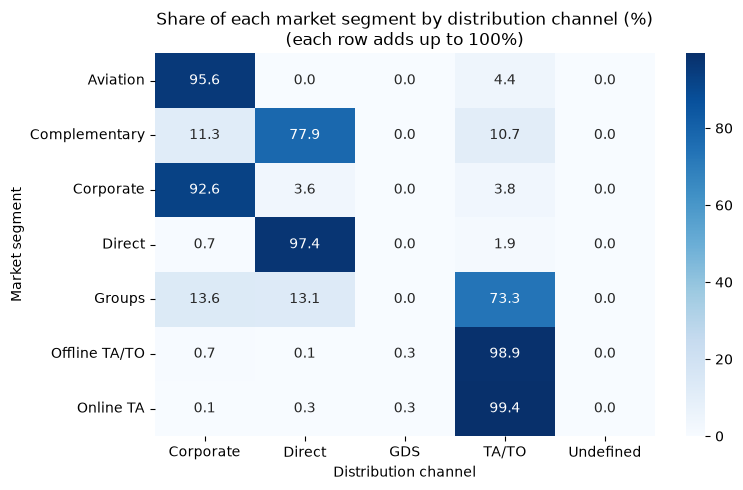

,main_channel,share_in_main_channel_%,bookings
market_segment,,,
Online TA,TA/TO,99.4,51543
Offline TA/TO,TA/TO,98.9,13857
Direct,Direct,97.4,11647
Groups,TA/TO,73.3,4937
Corporate,Corporate,92.6,4031
Complementary,Direct,77.9,698
Aviation,Corporate,95.6,227


In [ ]:
# Pair 1: market_segment x distribution_channel
seg_vs_channel = pd.crosstab(df["market_segment"], df["distribution_channel"], normalize="index") * 100

plt.figure(figsize=(8, 5))
sns.heatmap(seg_vs_channel, annot=True, fmt=".1f", cmap="Blues")
plt.title("Share of each market segment by distribution channel (%)\n(each row adds up to 100%)")
plt.xlabel("Distribution channel")
plt.ylabel("Market segment")
plt.tight_layout()
plt.show()

# For each segment: how much of it goes through its single most common channel?
summary = pd.DataFrame({
    "main_channel": seg_vs_channel.idxmax(axis=1),
    "share_in_main_channel_%": seg_vs_channel.max(axis=1).round(1),
    "bookings": df["market_segment"].value_counts(),
})
summary.sort_values("bookings", ascending=False)

**What we found:** knowing a booking's market segment predicts its distribution channel for **97.1% of bookings** (84,395 of 86,940). The large segments sit almost entirely in one channel: Online TA 99.4% TA/TO (51,543 bookings), Offline TA/TO 98.9% TA/TO (13,857), Direct 97.4% Direct (11,647), Corporate 92.6% Corporate (4,031). The reverse does not hold: the TA/TO channel contains three different segments (Online TA, Offline TA/TO and Groups), so the channel cannot tell them apart.

**Decision:** keep `market_segment` (more detailed) and drop `distribution_channel` from the clustering inputs, so the booking source is not counted twice in the distance. **Cost:** about 3% of bookings lose a little detail, mainly Groups, which are only 73.3% TA/TO (13.6% Corporate, 13.1% Direct). The classifiers keep both columns.

In [ ]:
# Pair 2: is_repeated_guest x "has any previous booking"
# has_previous is a temporary column for this check only. It is not added to df or saved
has_previous = (df["previous_cancellations"] + df["previous_bookings_not_canceled"]) > 0

repeat_vs_previous = pd.crosstab(df["is_repeated_guest"], has_previous, normalize="index") * 100
repeat_vs_previous.index = ["Not a repeat guest (0)", "Repeat guest (1)"]
repeat_vs_previous.columns = ["No previous booking", "Has previous booking"]
repeat_vs_previous.round(1)

,No previous booking,Has previous booking
Not a repeat guest (0),98.2,1.8
Repeat guest (1),14.8,85.2


**What we found:** the two columns overlap strongly but not perfectly. 98.2% of non-repeat guests have no previous booking, and 85.2% of repeat guests do have one. The two exceptions look like recording quirks rather than contradictions: 14.8% of repeat guests have no previous booking recorded (likely a past stay that was not linked to this booking), and 1.8% of non-repeat guests have a previous booking (likely guests whose only earlier booking was cancelled, so they never stayed). Because about 96% of bookings are 0 on both columns (Step 3), overall agreement looks high almost automatically; the repeat-guest row (85.2%) shows the real overlap.

**Decision:** no change. `is_repeated_guest`, `previous_cancellations` and `previous_bookings_not_canceled` were already dropped as near-constant in Step 3; this check confirms they carry overlapping information. The classifiers keep them.

## Step 5 · Skew: does a log transform help?

**What we check:** which numeric candidates are *skewed*, and whether a log transform fixes them.

**Why:** *skew* measures how lopsided a distribution is. 0 means balanced; above 1 means a strong long tail to the right (many small values, a few very large ones).

Before clustering, every column is put on the same ruler (scaled). A long tail stretches that ruler, so the normal bookings get squashed together and their real differences become hard to see. Example with five lead times (5, 10, 20, 30 and 600 days): on the ruler, the first four are squashed between −0.55 and −0.44 because the single 600-day booking stretches the scale. After a log, they spread from −1.02 to 0.01, about 10 times more room, so last-minute and month-ahead bookings can be told apart again.

A **log** squashes large values much more than small ones:

| Raw value | `log1p(value)` |
|---|---|
| 0 | 0 |
| 10 | 2.4 |
| 100 | 4.6 |
| 700 | 6.6 |

We use `log1p`, which is log(1 + x), because log(0) is undefined and many of these columns contain 0.

**A log does not fix every column.** There are three possible results:

| Result | What it means | What we do |
|---|---|---|
| Skew already ≤ 1 | Nothing to fix | Leave as is |
| Skew > 1, and ≤ 1 after log | A long tail that the log pulls in | Log it in notebook 12 |
| Skew > 1, still > 1 after log | A spike at 0, not a tail: zeros stay 0 after the log, so nothing spreads out | The log doesn't help. Usually means the column is near-constant (cross-check with Step 3) |

**Expected from earlier EDA:**
- *02_eda_univariate, Finding 2 (M2):* most numeric columns are right-skewed.
- *02_eda_univariate, Finding 3 (M2):* `adr` has a negative value (−6.38) and an extreme maximum (5,400), and `adults` has unusually large values. `log1p` of a negative number gives NaN, so **for this check only** we clip `adr` at 0. A temporary tweak like this is allowed by the team FAQ. The real fix is added to the Phase 3 To-Do (P3P-6).

**Where the log is actually applied:** not here. This notebook only decides **which** columns get logged. The log is applied in notebook 12, inside the clustering pipeline (log first, then scaling). It is not added to the shared feature engineering, because the tree-based classifiers (Random Forest, Gradient Boosting) split on thresholds and are not affected by a log, and the team FAQ says each modeller applies their own transforms.

In [ ]:
# Numeric candidates only (is_repeated_guest is a 0/1 flag, so skew does not apply)
numeric_candidates = []
for col in candidates:
    if pd.api.types.is_numeric_dtype(df[col]) and col != "is_repeated_guest":
        numeric_candidates.append(col)

temp = df[numeric_candidates].copy()   # a copy, so df is not changed
if "adr" in temp.columns:
    temp["adr"] = temp["adr"].clip(lower=0)  # temporary: log1p cannot handle negative values

skew_table = pd.DataFrame({
    "skew_before": temp.skew(),
    "skew_after_log1p": np.log1p(temp).skew(),
}).round(2)


def suggest(row):
    if abs(row["skew_before"]) <= 1:
        return "Leave as is"
    elif abs(row["skew_after_log1p"]) <= 1:
        return "Log in notebook 12"
    else:
        return "Log does not fix it: check Step 3"


skew_table["suggestion"] = skew_table.apply(suggest, axis=1)
skew_table.sort_values("skew_before", ascending=False)

,skew_before,skew_after_log1p,suggestion
previous_cancellations,34.38,10.48,Log does not fix it: check Step 3
babies,21.18,10.16,Log does not fix it: check Step 3
previous_bookings_not_canceled,20.89,7.22,Log does not fix it: check Step 3
adults,20.02,-0.97,Log in notebook 12
adr,11.01,-3.58,Log does not fix it: check Step 3
children,3.46,3.04,Log does not fix it: check Step 3
stays_in_week_nights,2.51,-0.15,Log in notebook 12
lead_time,1.43,-0.72,Log in notebook 12
stays_in_weekend_nights,1.31,0.09,Log in notebook 12


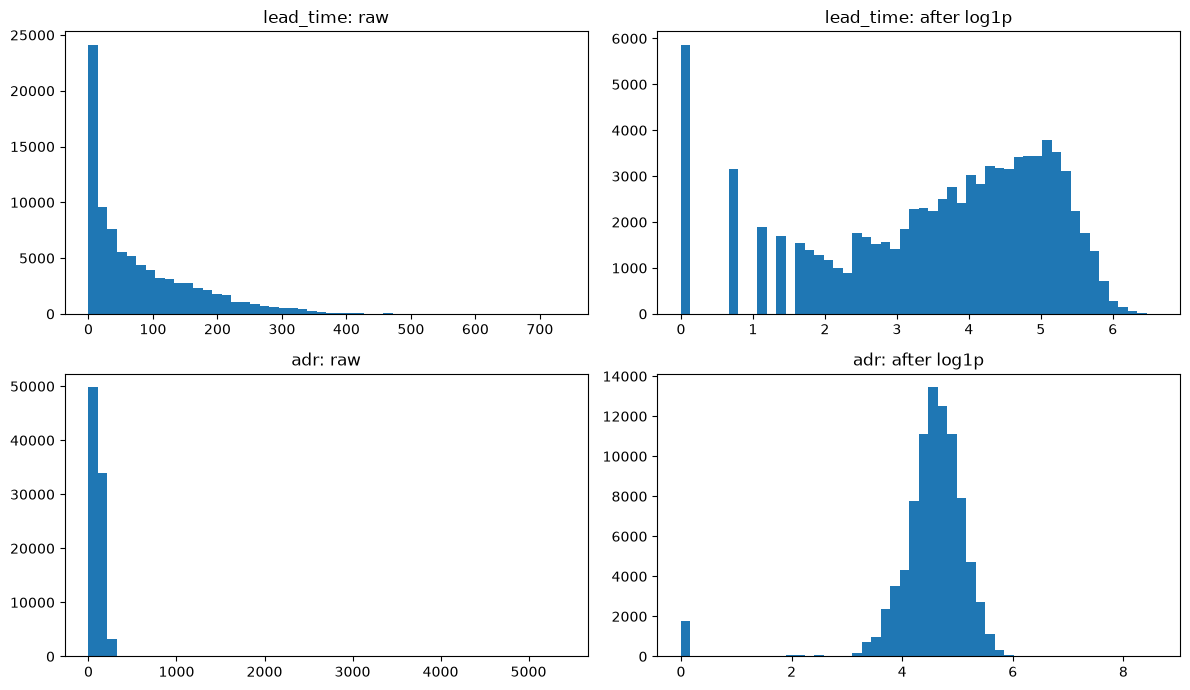

In [ ]:
# Before vs after the log, for the two main long-tail columns
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for i, col in enumerate(["lead_time", "adr"]):
    axes[i, 0].hist(temp[col], bins=50)
    axes[i, 0].set_title(f"{col}: raw")
    axes[i, 1].hist(np.log1p(temp[col]), bins=50)
    axes[i, 1].set_title(f"{col}: after log1p")

plt.tight_layout()
plt.show()

**What we found:**
- **Log fixes the skew:** `lead_time` (1.43 → −0.72), `stays_in_week_nights` (2.51 → −0.15), `stays_in_weekend_nights` (1.31 → 0.09), `adults` (20.02 → −0.97). The high skew of `adults` comes from just **16 bookings with more than 4 adults (maximum 55)**, 0.02% of the data (02_eda_univariate Finding 3), added to the Phase 3 To-Do (P3P-6). This shows how strongly a handful of extreme values can distort a column.
- **Log does not fix it (spike at 0):** `children` (3.46 → 3.04; 90% zeros, below the Step 3 line, so marked "Keep (review)"), and `babies`, `previous_cancellations` and `previous_bookings_not_canceled`, which confirms Step 3 (already dropped).
- **`adr`: the rule is misleading.** Skew goes from 11.01 to −3.58, which the rule labels "log does not fix it". The histogram shows the log does work on the main body (a clear hump around 4–5). The negative skew comes from the **1,762 bookings with adr = 0** (2.03%, Step 3), which sit far to the left after the log. Whether these zero-price bookings are genuine free stays or errors is a cleaning question, added to the Phase 3 To-Do (P3P-6) together with the negative value and the 5,400 outlier.
- **Reading note:** the separate bars at the left of the lead_time histogram after the log (0, 0.69, 1.1, 1.39) are whole days (0, 1, 2, 3 days ahead), not groups.

**Decision:** `lead_time`, `adr`, `adults` and both stay-night columns are log-transformed in notebook 12, inside the clustering pipeline. `adr` is set by hand (`manual_log` in Step 7) because the simple rule mislabelled it. `children` stays as "Keep (review)".

**Lesson:** a simple rule plus a plot beats either one alone. The skew number flagged `adr`, and the histogram showed why the number was misleading.

## Step 6 · Pairplot: do bookings form visible groups?

**What we check:** whether bookings already fall into visible groups before any clustering.

**Why:** this tells us what kind of clusters to expect, and which clustering method suits the data.

**What a pairplot is:** a grid of scatter plots of every chosen column against every other column. Each dot is one booking, and dots that are close together are bookings that look alike. The diagonal shows each column's own distribution. With `corner=True` only half the grid is drawn, because the other half is a mirror image.

**Choices:**
- **Sample of 5,000 bookings** (`random_state=42`). 87,000 dots would be slow to draw and would merge into one solid blob.
- **Columns:** `lead_time`, `adr`, the two stay-night columns and `adults`. The first four are log-transformed **only to make the plot readable**, for the same reason as Step 5. Nothing is saved.
- **Colour (`hue`) = `market_segment`**, our main "type of booking" column, **not `is_canceled`**. We are looking for structure *without* the target, the same as the clustering will.

**What to look for:**
- **Picture A (separate groups):** each colour sits in its own area of a plot. The numeric columns alone separate booking types, so K-Means on numbers could find good groups.
- **Picture B (one mixed cloud):** all colours overlap. The numbers alone don't separate booking types, so the differences live in the **categorical** columns (segment, meal, hotel, room type). Clustering then needs the categories too, which is a reason to try **K-Prototypes** (built for numbers and categories together) as well as K-Means (numbers only).

**Patterns that look like groups but aren't:** stripes from whole numbers (nights, adults), separate columns at the left of `lead_time` (0, 1, 2, 3 days after the log), and a line of dots at adr = 0 (zero-price bookings from Step 5).

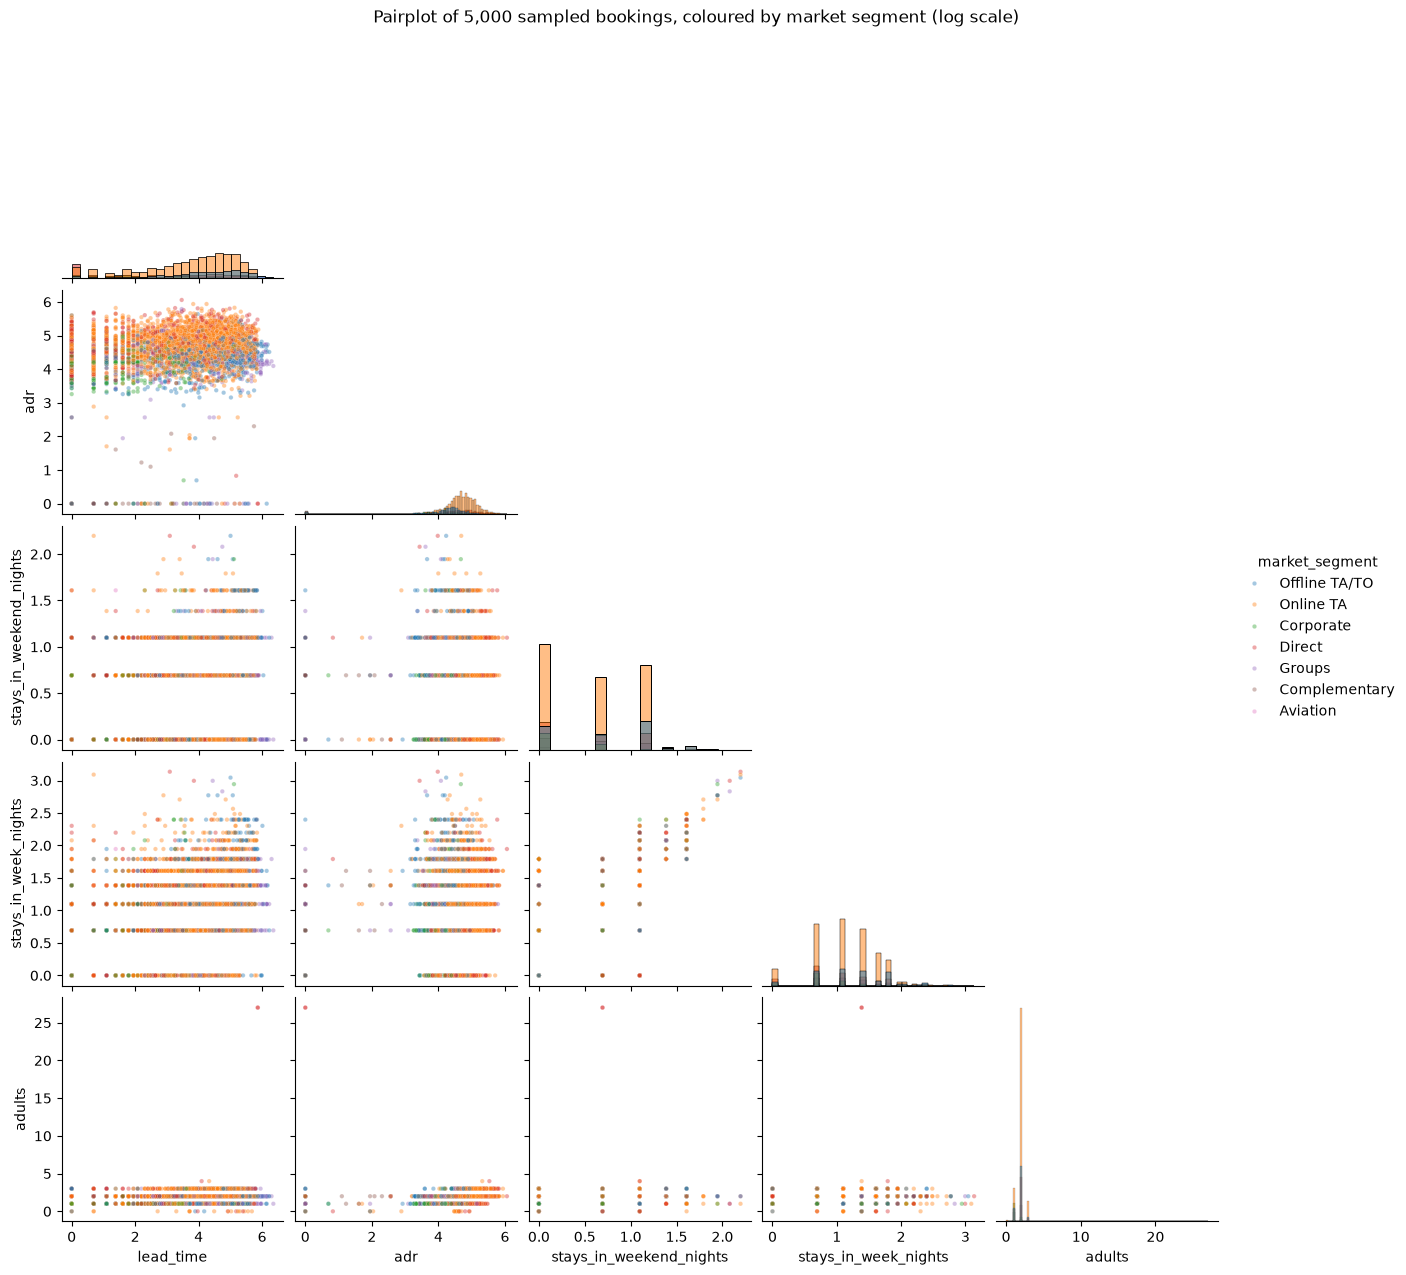

In [ ]:
sample = df.sample(5000, random_state=42)

plot_cols = ["lead_time", "adr", "stays_in_weekend_nights", "stays_in_week_nights", "adults"]
plot_df = sample[plot_cols].copy()

plot_df["adr"] = plot_df["adr"].clip(lower=0)  # same temporary clip as Step 5
for col in ["lead_time", "adr", "stays_in_weekend_nights", "stays_in_week_nights"]:
    plot_df[col] = np.log1p(plot_df[col])        # log only for readability of the plot

plot_df["market_segment"] = sample["market_segment"]

sns.pairplot(plot_df, hue="market_segment", corner=True, diag_kind="hist",
             plot_kws={"alpha": 0.4, "s": 10})
plt.suptitle("Pairplot of 5,000 sampled bookings, coloured by market segment (log scale)", y=1.02)
plt.show()

In [ ]:
# Exact numbers for the things seen in the pairplot (full data, not the sample)
print("Bookings with adr = 0:", (df["adr"] == 0).sum())
print("Highest adults value:", df["adults"].max())
print("Bookings with more than 4 adults:", (df["adults"] > 4).sum())

Bookings with adr = 0: 1762
Highest adults value: 55
Bookings with more than 4 adults: 16


**What we found:** closer to **Picture B**: one overlapping cloud. Online TA (59.29% of bookings, Step 3) covers every area, and no segment forms its own island. There are mild tendencies in the lead_time × adr cell: Offline TA/TO and Groups lean towards long lead times and slightly lower prices (likely tour operators and groups booking months ahead at negotiated rates), while Corporate and Direct lean towards short lead times.

Several visible patterns are **not** groups: horizontal stripes (whole-number nights and adults), a line of dots at adr = 0 (the 1,762 zero-price bookings from Step 5), and separate columns at the left of lead_time (0, 1, 2, 3 days after the log). One sampled booking with a very high adult count stretches the adults axis; in the full data the maximum is **55 adults**, and only **16 bookings** have more than 4. This explains the high adults skew in Step 5 and is listed in P3P-6. The weekend × week nights cell shows the moderate correlation found in EDA-II-9 (0.551): longer stays include both kinds of night. Limitation: the diagonal histograms are dominated by Online TA, so small segments are hard to see there.

**Decision:** the numeric columns alone do not separate booking types, so the categorical columns (`market_segment`, `hotel`, `meal`, `reserved_room_type`, `arrival_date_month`) must be part of the clustering inputs. Notebook 12 compares K-Means (with one-hot encoded categories) against K-Prototypes, which handles numbers and categories together, as planned in P4-06. `lead_time` and `adr` show the clearest segment tendencies among the numeric columns.

## Step 7 · Final candidate clustering feature list

**What this is:** every column passes through the same filters, in this order:

1. Target? - drop
2. Banned? - drop
3. ID code or row key? - drop
4. Calendar detail? - drop
5. Near-constant (Step 3)? - drop
6. Redundant (Step 4)? - drop

A column stops at the first filter it fails. The ones that pass every filter are the **candidate clustering features**: the input to notebook 12. Numeric survivors also get the Step 5 result:
- **Keep (log):** log-transform it in notebook 12.
- **Keep:** use as is.
- **Keep (review):** a grey area. Mostly zeros, so the log doesn't help (Step 5), but just below the 95% near-constant line (Step 3). It stays a candidate, but in notebook 12 we check whether it is more useful as a simple 0/1 flag (e.g. "has children: yes/no") or not at all.

**How the code works:** filters 1–5 and the log result are filled in automatically from Steps 2, 3 and 5. Two things are filled in **by hand**, because they are judgement calls based on what we saw:
- `redundant_drops`: columns dropped as redundant in Step 4 (`distribution_channel`).
- `manual_log`: columns the simple skew rule mislabelled in Step 5 (`adr`: the log works on its main body, see Step 5).

In [ ]:
# Filled in by hand after reading Step 4.
# Format: "column_name": "reason"
redundant_drops = {
    "distribution_channel": "Redundant with market_segment: segment predicts channel for 97.1% of bookings (Step 4)",
}

# Filled in by hand after reading Step 5: columns the simple skew rule mislabelled
manual_log = {
    "adr": "Log fixes the main body; the left tail comes from 1,762 zero-price bookings (Step 5, P3P-6)",
}

role_reasons = {
    "Target": "Target: clustering is unsupervised",
    "Row key": "Row key: used only to join files",
    "Banned": "Banned: not known at booking (D-5 / D-7 / Data Dictionary)",
    "ID code": "ID code: labels, not amounts (EDA-II-8)",
    "Calendar detail": "Calendar detail: collection period, repeats month, or not a booking trait (Step 2)",
}

decisions = []
reasons = []
for _, row in inventory.iterrows():
    col, role = row["column"], row["role"]

    if role != "Candidate":
        decision, reason = "Drop", role_reasons[role]
    elif col in near_constant_cols:
        share = near_constant_table.loc[near_constant_table["column"] == col, "top_share_%"].iloc[0]
        decision, reason = "Drop", f"Near-constant: {share}% one value (Step 3, D-8)"
    elif col in redundant_drops:
        decision, reason = "Drop", redundant_drops[col]
    elif col in manual_log:
        decision, reason = "Keep (log)", manual_log[col]
    elif col in skew_table.index and skew_table.loc[col, "suggestion"] == "Log in notebook 12":
        decision, reason = "Keep (log)", "Long tail: log fixes the skew (Step 5)"
    elif col in skew_table.index and skew_table.loc[col, "suggestion"].startswith("Log does not fix"):
        decision, reason = "Keep (review)", "Spike at 0: log doesn't help, but below the 95% line (Steps 3 + 5)"
    else:
        decision, reason = "Keep", "Passed every filter"

    decisions.append(decision)
    reasons.append(reason)

final_table = inventory.copy()
final_table["decision"] = decisions
final_table["reason"] = reasons
final_table

,column,role,decision,reason
0,booking_id,Row key,Drop,Row key: used only to join files
1,hotel,Candidate,Keep,Passed every filter
2,is_canceled,Target,Drop,Target: clustering is unsupervised
3,lead_time,Candidate,Keep (log),Long tail: log fixes the skew (Step 5)
4,arrival_date_year,Calendar detail,Drop,"Calendar detail: collection period, repeats mo..."
5,arrival_date_month,Candidate,Keep,Passed every filter
6,arrival_date_week_number,Calendar detail,Drop,"Calendar detail: collection period, repeats mo..."
7,arrival_date_day_of_month,Calendar detail,Drop,"Calendar detail: collection period, repeats mo..."
8,stays_in_weekend_nights,Candidate,Keep (log),Long tail: log fixes the skew (Step 5)
9,stays_in_week_nights,Candidate,Keep (log),Long tail: log fixes the skew (Step 5)


In [ ]:
clustering_features = final_table.loc[final_table["decision"].str.startswith("Keep"), "column"].tolist()

numeric_kept = [col for col in clustering_features if pd.api.types.is_numeric_dtype(df[col])]
categorical_kept = [col for col in clustering_features if col not in numeric_kept]
log_cols = final_table.loc[final_table["decision"] == "Keep (log)", "column"].tolist()

print(f"{len(clustering_features)} candidate clustering features:")
print(clustering_features)
print()
print("Numeric    :", numeric_kept)
print("Categorical:", categorical_kept)
print("Log in nb12:", log_cols)

11 candidate clustering features:
['hotel', 'lead_time', 'arrival_date_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'meal', 'market_segment', 'reserved_room_type', 'adr']

Numeric    : ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'adr']
Categorical: ['hotel', 'arrival_date_month', 'meal', 'market_segment', 'reserved_room_type']
Log in nb12: ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'adr']


**What we found:** **11 of 33 columns** pass every filter and become the candidate clustering features:

| Type | Columns | Treatment in notebook 12 |
|---|---|---|
| Numeric (6) | `lead_time`, `stays_in_weekend_nights`, `stays_in_week_nights`, `adults`, `adr` | Log, then scale (Step 5) |
| | `children` | Review: 90.39% zeros (Steps 3 + 5); test as a 0/1 "has children" flag |
| Categorical (5) | `hotel`, `arrival_date_month`, `meal`, `market_segment`, `reserved_room_type` | Encode (one-hot for K-Means; used directly by K-Prototypes) |

The other 22 columns are dropped from clustering: 16 by role (Step 2), 5 as near-constant (Step 3) and 1 as redundant (Step 4). Every drop and its reason is in the table above.

**Decision (D-9):** these 11 columns are the candidate inputs for `12_clustering`. Copy the printed `clustering_features` and `log_cols` lists into notebook 12.

**Why the numeric/categorical split matters:** K-Means works with numbers only, so categorical columns would have to be one-hot encoded (one 0/1 column per category). K-Prototypes handles numbers and categories together. With 5 of the 11 inputs categorical, and the Step 6 pairplot looking like Picture B (the numbers alone do not separate booking types), notebook 12 compares the two methods, as P4-06 already plans.

## Step 8 · Top 5 insights and sheet updates

### Top 5 insights (copy into the EDA Insights tab)

| ID | Owner | Finding | Why it matters for our task |
|---|---|---|---|
| EDA-IV-1 | M1 | 5 of 17 candidate columns are near-constant: `babies` (98.95% are 0), `deposit_type` (98.68% No Deposit), `previous_cancellations` (98.09% are 0), `previous_bookings_not_canceled` (96.18% are 0), `is_repeated_guest` (96.08% are 0). There is a natural gap down to the next column, `children` (90.39%). | Clustering: these barely change the distance between bookings (or push the rare ones into a tiny cluster after scaling), so they are dropped from the clustering inputs only. The classifiers keep them. |
| EDA-IV-2 | M1 | `market_segment` predicts `distribution_channel` for 97.1% of bookings (e.g. Online TA: 99.4% through TA/TO). The reverse does not hold: TA/TO contains Online TA, Offline TA/TO and Groups. | Clustering: keep only `market_segment`, so the booking source is not counted twice in the distance. |
| EDA-IV-3 | M1 | A log fixes the skew of `lead_time` (1.43 → −0.72), `stays_in_week_nights` (2.51 → −0.15), `stays_in_weekend_nights` (1.31 → 0.09) and `adults` (20.02 → −0.97; driven by just 16 bookings with more than 4 adults, max 55). For `adr`, the log works on the main body, but 1,762 zero-price bookings create a left tail. | Clustering: these 5 columns are log-transformed in the notebook 12 pipeline, so a few extreme bookings don't squash everyone else. The adr and adults extremes go to Phase 3 (P3P-6). |
| EDA-IV-4 | M1 | The pairplot shows one overlapping cloud (Picture B): no market segment forms its own group. Segments only lean: Offline TA/TO and Groups towards long lead times, Corporate and Direct towards short ones. | Clustering: the numeric columns alone won't separate booking types, so categorical columns must be included, which supports comparing K-Means (one-hot) with K-Prototypes. |
| EDA-IV-5 | M1 | 11 of 33 columns survive all filters: 6 numeric (5 to be logged, `children` under review) and 5 categorical. | Clustering: this is the input list for notebook 12 (D-9). |

### What this notebook does not do

No rows or columns were changed, and nothing was saved. Scaling, encoding and the log transforms happen in notebook 12, inside the clustering pipeline, and are learned from the training data only.